# Face Auth Dataset Generation — Final (Colab T4, resumable)

Two classes:
- **class_A** = `me` + `teammate` (125 base images each -> 500 final combined)
- **class_B** = `professor` (250 base images -> 500 final)

Engine: SD1.5 + IP-Adapter-FaceID (embedding-conditioned, no LoRA, no CLIP
vision encoder — lightest identity-preserving option, and pose/age/lighting
are controlled by prompt instead of being limited by img2img strength).

**Generation runs in small batches on purpose** — one cell execution
generating hundreds of images ran long enough that Colab's browser
websocket to the kernel timed out and disconnected. Every batch cell
saves to Drive and to `generation_manifest.csv` immediately, so just
re-run the batch cell as many times as needed; it always resumes from
what's already on disk.

Run cells top to bottom once, then repeat the "Generate — batch" cell
until the printed counts hit target.


In [1]:
import sys
import torch

print("Python:", sys.version)
print("Executable:", sys.executable)
print("Torch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
import einops
print("einops OK:", einops.__version__)

from ip_adapter.ip_adapter_faceid import IPAdapterFaceID
print("IP-Adapter FaceID import OK")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Executable: d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Scripts\python.exe
Torch: 2.6.0+cu124
CUDA: True
einops OK: 0.7.0


d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


IP-Adapter FaceID import OK
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import numpy
import cv2
import diffusers
import transformers
import insightface

print("NumPy:", numpy.__version__)
print("OpenCV:", cv2.__version__)
print("Diffusers:", diffusers.__version__)
print("Transformers:", transformers.__version__)
print("InsightFace:", insightface.__version__)

NumPy: 2.4.6
OpenCV: 5.0.0
Diffusers: 0.27.2
Transformers: 4.38.2
InsightFace: 0.7.3


In [4]:
!nvidia-smi

Sun Aug 23 19:16:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 581.86                 Driver Version: 581.86         CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8              1W /  115W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Install
Plain Colab Python — no system Python-version switching, no force-reinstalls.
`numpy<2` is pinned deliberately: several packages here (opencv, insightface)
ship wheels built against NumPy 1.x, and Colab's default NumPy 2.x breaks
their C extension ABI at import time (`_ARRAY_API not found`). Pinning
numpy down avoids that class of error entirely instead of chasing it
package by package.

**Restart the runtime now** (Runtime -> Restart session), then continue from the next cell. This is required after any pip install that changes numpy/opencv/huggingface_hub - a kernel that already imported the old versions won't pick up the new ones otherwise.

## Project setup

In [2]:
from pathlib import Path

# Local project directory
PROJECT = Path.cwd() / "face_auth_project_v2"

REFERENCE = PROJECT / "reference"
GENERATED = PROJECT / "generated"
DATASET = PROJECT / "dataset"
INPUTS = PROJECT / "inputs"

PEOPLE = ["me", "teammate", "professor"]

CLASS_MAP = {
    "me": "class_A",
    "teammate": "class_A",
    "professor": "class_B",
}

CLASSES = sorted(set(CLASS_MAP.values()))

for person in PEOPLE:
    (REFERENCE / person).mkdir(parents=True, exist_ok=True)
    (GENERATED / person).mkdir(parents=True, exist_ok=True)

INPUTS.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT)
print("People:", PEOPLE)
print("Class map:", CLASS_MAP)
print("Inputs:", INPUTS)

Project: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2
People: ['me', 'teammate', 'professor']
Class map: {'me': 'class_A', 'teammate': 'class_A', 'professor': 'class_B'}
Inputs: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\inputs


## Upload reference photos
One clear photo per person in `PEOPLE`, named `<person>.jpg` (e.g. `me.jpg`, `teammate.jpg`, `professor.jpg`).

In [6]:
source_files = {
    person: INPUTS / f"{person}.jpg"
    for person in PEOPLE
}

for person, path in source_files.items():
    print(person, "->", path, "exists:", path.exists())

me -> d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\inputs\me.jpg exists: True
teammate -> d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\inputs\teammate.jpg exists: True
professor -> d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\inputs\professor.jpg exists: True


## Fix rotation / orientation
`ImageOps.exif_transpose` fixes phone EXIF rotation automatically. If a
photo is *still* sideways after that, set its degrees below (try 90, -90,
or 180) and re-run this cell, then the preview cell.

In [7]:
from PIL import Image, ImageOps

MANUAL_ROTATE_DEGREES = {
    "me": 0,
    "teammate": 0,
    "professor": 0,
}

MAX_DIM = 768

def normalize_reference(person, source_path):
    image = Image.open(source_path)
    image = ImageOps.exif_transpose(image)
    image = image.convert("RGB")

    degrees = MANUAL_ROTATE_DEGREES.get(person, 0)
    if degrees:
        image = image.rotate(degrees, expand=True, fillcolor=(0, 0, 0))

    image.thumbnail((MAX_DIM, MAX_DIM))

    dest = REFERENCE / person / "reference.jpg"
    image.save(dest, format="JPEG", quality=95)
    return image

reference_images = {}
for person, source in source_files.items():
    if not source.exists():
        raise FileNotFoundError(f"Reference image not found: {source}. Upload it above.")
    reference_images[person] = normalize_reference(person, source)
    print(f"{person}: normalized -> {REFERENCE / person / 'reference.jpg'} "
          f"(rotation applied: {MANUAL_ROTATE_DEGREES.get(person, 0)} deg)")

me: normalized -> d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\reference\me\reference.jpg (rotation applied: 0 deg)
teammate: normalized -> d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\reference\teammate\reference.jpg (rotation applied: 0 deg)
professor: normalized -> d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\reference\professor\reference.jpg (rotation applied: 0 deg)


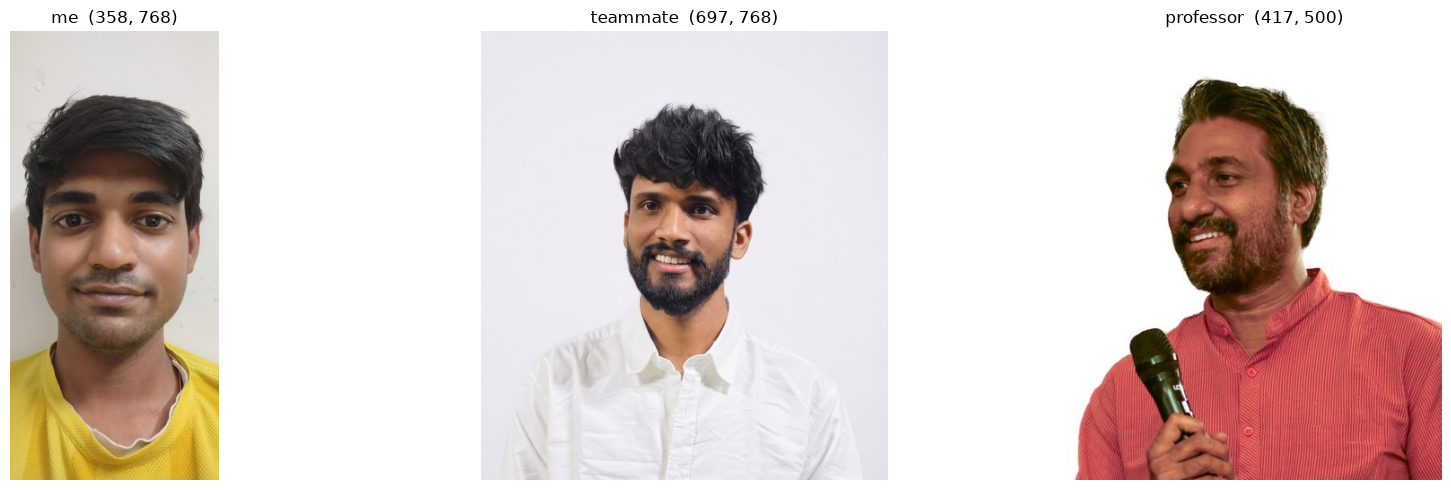

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(PEOPLE), figsize=(6 * len(PEOPLE), 5))
if len(PEOPLE) == 1:
    axes = [axes]
for ax, person in zip(axes, PEOPLE):
    img = Image.open(REFERENCE / person / "reference.jpg")
    ax.imshow(img)
    ax.set_title(f"{person}  {img.size}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## Low-VRAM toggle
`LOW_VRAM = False` is correct for Colab T4 — SD1.5 + FaceID fits in ~5GB,
no offload needed, and offload makes each generation slower (which works
against keeping batch cells short). Set `True` only on a local GPU with
<=8GB VRAM.

insightface always runs on CPU regardless of this toggle — it's cheap
either way, and keeping it off the GPU means the diffusion model never
has to share VRAM with it during the per-image quality check.

In [9]:
LOW_VRAM = True

## Face detection + identity embeddings (insightface, buffalo_l, CPU)

In [10]:
from insightface.app import FaceAnalysis
import cv2
import torch
import numpy as np

face_app = FaceAnalysis(
    name="buffalo_l",
    providers=["CPUExecutionProvider"],
)
face_app.prepare(ctx_id=-1, det_size=(640, 640))

def get_primary_face(bgr_image):
    faces = face_app.get(bgr_image)
    if not faces:
        return None
    faces.sort(key=lambda f: (f.bbox[2] - f.bbox[0]) * (f.bbox[3] - f.bbox[1]), reverse=True)
    return faces[0]

def cosine_distance(a, b):
    a, b = a.flatten(), b.flatten()
    return 1.0 - float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-8))

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\w600k_r50.onnx recognition ['None', 3, 112, 112]

In [32]:
# Extract + sanity-check one face per reference photo.
# If this fails for someone, go back to "Fix rotation" and correct their
# photo before continuing.
reference_embeds = {}

for person in PEOPLE:
    path = REFERENCE / person / "reference.jpg"
    bgr = cv2.imread(str(path))
    faces = face_app.get(bgr)

    print(f"{person}: {len(faces)} face(s) detected")
    if len(faces) == 0:
        raise RuntimeError(f"No face detected for {person}. Fix the photo and retry.")
    if len(faces) > 1:
        print(f"  WARNING: {len(faces)} faces found, using the largest as the subject.")

    face = get_primary_face(bgr)
    reference_embeds[person] = torch.from_numpy(face.normed_embedding).unsqueeze(0)
    print(f"  embedding ok, bbox size ~{int(min(face.bbox[2]-face.bbox[0], face.bbox[3]-face.bbox[1]))}px")

print("\nAll reference embeddings extracted.")

d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


me: 1 face(s) detected
  embedding ok, bbox size ~253px
teammate: 1 face(s) detected
  embedding ok, bbox size ~182px
professor: 1 face(s) detected
  embedding ok, bbox size ~130px

All reference embeddings extracted.


## Load the generation model
SD1.5 (Realistic Vision) + IP-Adapter-FaceID. No LoRA fusing, no CLIP
image encoder. First run downloads a few GB; cached after that.

In [33]:
from diffusers import StableDiffusionPipeline, DDIMScheduler, AutoencoderKL
from huggingface_hub import hf_hub_download
from ip_adapter.ip_adapter_faceid import IPAdapterFaceID

base_model_path = "SG161222/Realistic_Vision_V4.0_noVAE"
vae_model_path = "stabilityai/sd-vae-ft-mse"
device = "cuda"

noise_scheduler = DDIMScheduler(
    num_train_timesteps=1000,
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    clip_sample=False,
    set_alpha_to_one=False,
    steps_offset=1,
)

vae = AutoencoderKL.from_pretrained(vae_model_path, torch_dtype=torch.float16)

pipe = StableDiffusionPipeline.from_pretrained(
    base_model_path,
    torch_dtype=torch.float16,
    scheduler=noise_scheduler,
    vae=vae,
    feature_extractor=None,
    safety_checker=None,
)

if LOW_VRAM:
    pipe.enable_model_cpu_offload()
else:
    pipe = pipe.to(device)

pipe.enable_attention_slicing()
try:
    pipe.enable_vae_slicing()
except Exception:
    pass

ip_ckpt = hf_hub_download("h94/IP-Adapter-FaceID", "ip-adapter-faceid_sd15.bin")
ip_model = IPAdapterFaceID(pipe, ip_ckpt, device)

print("Model + IP-Adapter-FaceID loaded.")

d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\huggingface_hub\file_download.py:1150: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Loading pipeline components...: 100%|██████████| 5/5 [00:06<00:00,  1.39s/it]
It seems like you have activated model offloading by calling `enable_model_cpu_offload`, but are now manually moving the pipeline to GPU. It is strongly recommended against doing so as memory gains from offloading are likely to be lost. Offloading automatically takes care of moving the individual components vae, text_encoder, tokenizer, unet, scheduler, safety_checker, feature_extractor, image_encoder to GPU when needed. To make sure offloading works as expected, you should consider moving the pipeline back to CPU: `pipeline.to('cpu')` or removing the move altogether if you use offloading.
d:\Jai\IITT\Sem 7\CSS\fac

Model + IP-Adapter-FaceID loaded.


## Prompt bank — scale, lighting, pose, and aging as separate axes

In [34]:
PROMPT_TEMPLATES = [
    (
        "id_front",
        "photorealistic identity verification photograph of the same person, "
        "front-facing straight-on face, looking directly into the camera, "
        "neutral expression, natural facial proportions, "
        "realistic skin texture, head and shoulders, "
        "centered composition, even soft lighting, "
        "plain white background, single person"
    ),

    (
        "id_studio",
        "photorealistic passport-style photograph of the same person, "
        "straight frontal view, looking directly at camera, "
        "neutral expression, natural skin tone, "
        "realistic facial proportions, head and shoulders, "
        "soft even illumination, plain white background, "
        "single person, centered"
    ),

    (
        "id_clean",
        "realistic photograph of the same person, "
        "clear frontal face, direct eye contact with camera, "
        "neutral expression, natural skin and hair, "
        "realistic facial proportions, "
        "head and shoulders, plain white background, "
        "single person, centered"
    ),
]

negative_prompt = (
    "different person, different identity, woman, female "
    "gender change, changed ethnicity, changed skin color, "
    "cartoon, anime, illustration, painting, 3d render, CGI, "
    "stylized, fantasy, beauty filter, makeup, "
    "side profile, extreme angle, looking away, "
    "multiple people, multiple faces, duplicate face, "
    "deformed face, distorted face, asymmetrical face, "
    "bad anatomy, extra eyes, extra nose, malformed eyes, "
    "blurry, low resolution, unrealistic skin, plastic skin, "
    "watermark, text"
)

print(f"{len(PROMPT_TEMPLATES)} prompt templates covering: "
      f"{sorted(set(c for c,_ in PROMPT_TEMPLATES))}")

3 prompt templates covering: ['id_clean', 'id_front', 'id_studio']


## Generation targets — split by class, not by person
`class_A` (me + teammate) and `class_B` (professor) each end up with
~500 final images: class_A's budget is split across its 2 people so
neither class ends up double-sized after augmentation.

In [48]:
TOTAL_BASE_PER_CLASS = 250   # pre-augmentation; doubles to 500 final per CLASS after 1 augmentation/image
MAX_IDENTITY_COSINE_DISTANCE = 0.5  # raise toward 0.60 if too many generations get rejected
MIN_FACE_SIZE_PX = 60
GEN_WIDTH, GEN_HEIGHT = 512, 512
NUM_INFERENCE_STEPS = 30
BASE_SEED = 10000
BATCH_SIZE = 5   # images ATTEMPTED per cell execution - keeps each run short so Colab doesn't disconnect

from collections import Counter
class_sizes = Counter(CLASS_MAP[p] for p in PEOPLE)
PER_PERSON_TARGET = {p: TOTAL_BASE_PER_CLASS // class_sizes[CLASS_MAP[p]] for p in PEOPLE}
print("Per-person targets:", PER_PERSON_TARGET)

Per-person targets: {'me': 125, 'teammate': 125, 'professor': 250}


## Generation functions

In [55]:
import gc
import pandas as pd
from datetime import datetime

def generate_one(person, prompt, seed):
    images = ip_model.generate(
        prompt=prompt,
        negative_prompt=negative_prompt,
        faceid_embeds=reference_embeds[person],
        num_samples=1,
        width=512,
        height=512,
        num_inference_steps=30,
        guidance_scale=7.5,
        scale=1.0,
        seed=seed,
    )

    return images[0]

def quality_check(pil_image, person):
    bgr = cv2.cvtColor(np.array(pil_image), cv2.COLOR_RGB2BGR)
    face = get_primary_face(bgr)
    if face is None:
        return False, 1.0, 0.0
    dist = cosine_distance(reference_embeds[person].numpy(), face.normed_embedding)
    size = min(face.bbox[2]-face.bbox[0], face.bbox[3]-face.bbox[1])
    passed = dist <= MAX_IDENTITY_COSINE_DISTANCE and size >= MIN_FACE_SIZE_PX
    return passed, dist, size

## Generate — batch (RE-RUN THIS CELL REPEATEDLY)
Each execution attempts up to `BATCH_SIZE` accepted images **per person**,
then stops and saves. This keeps each run to a couple of minutes instead
of running long enough for Colab's connection to time out. Just keep
clicking run on this cell — it always resumes from what's on Drive —
until the printed counts show every person at their target.

In [58]:
test_person = "me"
test_prompt = (
    "realistic photograph of the same person, "
    "front-facing head and shoulders portrait, "
    "looking directly at the camera, neutral expression, "
    "natural skin texture, realistic photography, "
    "plain light gray background"
)

for s in [1.0, 1.2, 1.3, 1.5]:
    img = ip_model.generate(
        prompt=test_prompt,
        negative_prompt=negative_prompt,
        faceid_embeds=reference_embeds[test_person],
        num_samples=1,
        width=512,
        height=512,
        num_inference_steps=30,
        guidance_scale=7.5,
        scale=s,
        seed=1234,
    )[0]

    img.save(f"face_test_scale_{s}.jpg")
    print("saved", s)

100%|██████████| 30/30 [00:15<00:00,  1.94it/s]


saved 1.0


100%|██████████| 30/30 [00:05<00:00,  5.63it/s]


saved 1.2


100%|██████████| 30/30 [00:05<00:00,  5.74it/s]


saved 1.3


100%|██████████| 30/30 [00:05<00:00,  5.73it/s]


saved 1.5


In [61]:
manifest_path = PROJECT / "generation_manifest.csv"
if manifest_path.exists():
    generation_manifest = pd.read_csv(manifest_path)
    generation_records = generation_manifest.to_dict("records")
else:
    generation_records = []

for person in PEOPLE:
    person = "professor"
    out_dir = GENERATED / person
    out_dir.mkdir(parents=True, exist_ok=True)
    existing = {p.name for p in out_dir.glob("*.jpg")}
    target = PER_PERSON_TARGET[person]
    n_passed = len(existing)

    print(f"\n{person}: {n_passed}/{target} already on disk")
    if n_passed >= target:
        print(f"  {person} already complete, skipping.")
        continue

    attempt = 0
    made_this_batch = 0
    max_attempts = BATCH_SIZE * 4  # ceiling so a bad threshold can't hang this batch

    while n_passed < target and made_this_batch < BATCH_SIZE and attempt < max_attempts:
        prompt_index = attempt % len(PROMPT_TEMPLATES)
        category, prompt = PROMPT_TEMPLATES[prompt_index]
        seed = BASE_SEED + n_passed + attempt
        fname = f"{person}_{n_passed:04d}.jpg"
        attempt += 1

        if fname in existing:
            continue

        try:
            image = generate_one(person, prompt, seed)
        except Exception as e:
            print(f"  [{person}] generation failed: {e}")
            torch.cuda.empty_cache(); gc.collect()
            continue

        passed, dist, size = quality_check(image, person)
        if passed:
            image.save(out_dir / fname, format="JPEG", quality=95)
            existing.add(fname)
            n_passed += 1
            made_this_batch += 1
            print(f"  [{person}] {n_passed}/{target} (identity_dist={dist:.3f})")

        generation_records.append({
            "person": person, "filename": fname, "prompt_index": prompt_index,
            "category": category, "prompt": prompt, "seed": seed,
            "identity_cosine_distance": round(dist, 4), "face_size_px": round(size, 1),
            "passed": passed, "timestamp": datetime.now().isoformat(),
        })

        del image
        torch.cuda.empty_cache(); gc.collect()

    print(f"[{person}] batch done: {n_passed}/{target}")

    # save manifest after EVERY person's batch, not just at the end
    pd.DataFrame(generation_records).to_csv(manifest_path, index=False)

print("\nSaved:", manifest_path)
print("Re-run this cell as many times as needed - it resumes automatically.")


professor: 14/250 already on disk


100%|██████████| 30/30 [00:05<00:00,  5.48it/s]
d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


  [professor] 15/250 (identity_dist=0.326)


100%|██████████| 30/30 [00:05<00:00,  5.65it/s]


  [professor] 16/250 (identity_dist=0.314)


...

  [professor] 27/250 (identity_dist=0.317)


100%|██████████| 30/30 [00:05<00:00,  5.83it/s]


  [professor] 28/250 (identity_dist=0.426)


100%|██████████| 30/30 [00:05<00:00,  5.88it/s]


  [professor] 29/250 (identity_dist=0.336)
[professor] batch done: 29/250

Saved: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\generation_manifest.csv
Re-run this cell as many times as needed - it resumes automatically.


## Verify synthetic originals
Run after the batch cell shows every person at target.

In [69]:
# ## Verify synthetic originals
# We intentionally stopped AI generation at ~30 good images/person.
# Remaining dataset size will come from conventional augmentation.

print("=" * 60)
print("VERIFYING SYNTHETIC ORIGINALS")
print("=" * 60)

MIN_SYNTHETIC_PER_PERSON = 20

actual_counts = {}

for person in PEOPLE:
    person_dir = GENERATED / person

    images = sorted(
        p for p in person_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    )

    actual_counts[person] = len(images)

    print(f"{person:12s}: {len(images)} synthetic originals")

    if len(images) < MIN_SYNTHETIC_PER_PERSON:
        print(f"  WARNING: only {len(images)} images found.")

print("\nSynthetic generation stage complete.")
print("Proceeding with the available images.")

VERIFYING SYNTHETIC ORIGINALS
me          : 29 synthetic originals
teammate    : 30 synthetic originals
professor   : 30 synthetic originals

Synthetic generation stage complete.
Proceeding with the available images.


## Split — 80/10/10, BEFORE augmentation (anti-leakage), stratified by prompt category

In [70]:
for person in PEOPLE:
    disk_files = {
        p.name
        for p in (GENERATED / person).iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    }

    manifest_files = set(
        generation_manifest[
            (generation_manifest["person"] == person) &
            (generation_manifest["passed"] == True)
        ]["filename"]
    )

    missing = manifest_files - disk_files

    print(f"\n{person}")
    print("Manifest passing:", len(manifest_files))
    print("Files on disk:   ", len(disk_files))
    print("Missing files:   ", len(missing))

    if missing:
        print("Examples:", list(missing)[:5])


me
Manifest passing: 33
Files on disk:    29
Missing files:    5
Examples: ['me_0031.jpg', 'me_0032.jpg', 'me_0033.jpg', 'me_0029.jpg', 'me_0030.jpg']

teammate
Manifest passing: 40
Files on disk:    30
Missing files:    10
Examples: ['teammate_0033.jpg', 'teammate_0035.jpg', 'teammate_0034.jpg', 'teammate_0038.jpg', 'teammate_0032.jpg']

professor
Manifest passing: 29
Files on disk:    30
Missing files:    0


In [68]:
from sklearn.model_selection import train_test_split
import pandas as pd

TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.80, 0.10, 0.10

for cls in CLASSES:
    for split in ["train", "val", "test"]:
        (DATASET / cls / split).mkdir(parents=True, exist_ok=True)

generation_manifest = pd.read_csv(PROJECT / "generation_manifest.csv")

split_records = []
for person in PEOPLE:
    person_df = generation_manifest[
        (generation_manifest["person"] == person) & (generation_manifest["passed"] == True)
    ].copy()

    if len(person_df) < 10:
        raise ValueError(f"{person}: only {len(person_df)} passing images, too few to split. "
                          f"Run more generation batches first.")

    train_df, temp_df = train_test_split(
        person_df,
        test_size=(VAL_RATIO + TEST_RATIO),
        random_state=42,
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
        random_state=43,
    )

    train_df = train_df.copy(); val_df = val_df.copy(); test_df = test_df.copy()
    train_df["split"] = "train"; val_df["split"] = "val"; test_df["split"] = "test"

    person_split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
    for _, row in person_split_df.iterrows():
        split_records.append({
            "person": row["person"], "class_name": CLASS_MAP[row["person"]],
            "source_filename": row["filename"], "prompt_index": row["prompt_index"],
            "category": row["category"], "split": row["split"],
        })

    print(f"{person} ({CLASS_MAP[person]}): train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")

split_manifest = pd.DataFrame(split_records)
split_manifest_path = PROJECT / "source_split_manifest.csv"
split_manifest.to_csv(split_manifest_path, index=False)
print("\nSaved:", split_manifest_path)

me (class_A): train=45, val=6, test=6
teammate (class_A): train=40, val=5, test=5
professor (class_B): train=39, val=5, test=5

Saved: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\source_split_manifest.csv


## Augment — inside each split only (the 4 required techniques, one per original image, cycled)

In [13]:
import albumentations as A

augmentation_transforms = {
    "horizontal_flip": A.Compose([
        A.HorizontalFlip(p=1.0)
    ]),

    "brightness": A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.12,
            contrast_limit=0.05,
            p=1.0
        )
    ]),

    "rotation": A.Compose([
        A.Rotate(
            limit=8,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        )
    ]),

    "gaussian_noise": A.Compose([
        A.GaussNoise(
            std_range=(0.01, 0.04),
            p=1.0
        )
    ]),
}
augmentation_names = list(augmentation_transforms.keys())
print("Augmentations:", augmentation_names)

Augmentations: ['horizontal_flip', 'brightness', 'rotation', 'gaussian_noise']


In [65]:
import shutil
from tqdm import tqdm

if DATASET.exists():
    print("Removing previous dataset...")
    shutil.rmtree(DATASET)
for cls in CLASSES:
    for split in ["train", "val", "test"]:
        (DATASET / cls / split).mkdir(parents=True, exist_ok=True)

final_records = []

for person in PEOPLE:
    cls = CLASS_MAP[person]
    print("\n" + "=" * 60)
    print(f"BUILDING DATASET FOR: {person} -> {cls}")
    print("=" * 60)

    person_split_df = split_manifest[split_manifest["person"] == person].copy()

    for split in ["train", "val", "test"]:
        split_df = person_split_df[person_split_df["split"] == split].reset_index(drop=True)
        print(f"\n{split.upper()}: {len(split_df)} original images")

        for idx, row in tqdm(split_df.iterrows(), total=len(split_df), desc=f"{person} {split}"):
            source_path = GENERATED / person / row["source_filename"]
            if not source_path.exists():
                print(f"  MISSING: {source_path}")
                continue

            image = Image.open(source_path).convert("RGB")
            image_np = np.array(image)

            # 1. save original into its CLASS folder
            orig_name = f"{person}_{split}_original_{idx:04d}.jpg"
            Image.fromarray(image_np).save(DATASET / cls / split / orig_name, quality=95)
            final_records.append({
                "filename": orig_name, "person": person, "class_name": cls, "split": split,
                "data_type": "original", "augmentation": "none", "source_filename": row["source_filename"],
            })

            # 2. one augmented copy, cycling through the 4 techniques
            # Generate ALL 4 augmentation variants
            for aug_name_type, transform in augmentation_transforms.items():

                augmented_np = transform(image=image_np)["image"]

                aug_name = (
                    f"{person}_{split}_aug_"
                    f"{aug_name_type}_{idx:04d}.jpg"
                )

                Image.fromarray(augmented_np).save(
                    DATASET / cls / split / aug_name,
                    quality=95
                )

                final_records.append({
                    "filename": aug_name,
                    "person": person,
                    "class_name": cls,
                    "split": split,
                    "data_type": "conventional_augmented",
                    "augmentation": aug_name_type,
                    "source_filename": row["source_filename"],
                })

final_manifest = pd.DataFrame(final_records)
final_manifest_path = PROJECT / "final_manifest.csv"
final_manifest.to_csv(final_manifest_path, index=False)
print("\nSaved:", final_manifest_path)

Removing previous dataset...

BUILDING DATASET FOR: me -> class_A

TRAIN: 45 original images


me train:  31%|███       | 14/45 [00:00<00:00, 31.79it/s]

  MISSING: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\generated\me\me_0025.jpg
  MISSING: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\generated\me\me_0030.jpg


me train:  49%|████▉     | 22/45 [00:00<00:00, 29.62it/s]

  MISSING: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\generated\me\me_0031.jpg


...


VAL: 5 original images


professor val: 100%|██████████| 5/5 [00:00<00:00, 24.68it/s]



TEST: 5 original images


professor test: 100%|██████████| 5/5 [00:00<00:00, 24.24it/s]


Saved: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\final_manifest.csv


## Final verification: counts per class, augmentation distribution, prompt distribution, split isolation

In [ ]:
print("=" * 70)
print("FINAL DATASET VERIFICATION (per class)")
print("=" * 70)

final_target = TOTAL_BASE_PER_CLASS * 2
expected = {
    "train": int(final_target * TRAIN_RATIO),
    "val": int(final_target * VAL_RATIO),
    "test": final_target - int(final_target * TRAIN_RATIO) - int(final_target * VAL_RATIO),
}

for cls in CLASSES:
    print(f"\n{cls.upper()}")
    total = 0
    for split in ["train", "val", "test"]:
        split_dir = DATASET / cls / split
        images = [p for p in split_dir.iterdir() if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]
        count = len(images)
        print(f"  {split:5s}: {count:3d} (expected ~{expected[split]})")
        total += count
    print(f"  TOTAL: {total} (target {final_target})")
    if total < 500:
        print(f"  WARNING: below the 500 minimum.")

print("\nDone.")

In [ ]:
print("=" * 70)
print("AUGMENTATION DISTRIBUTION (per class)")
print("=" * 70)
augmented_only = final_manifest[final_manifest["data_type"] == "conventional_augmented"]
print(augmented_only.groupby(["class_name", "split", "augmentation"]).size().unstack(fill_value=0))

In [ ]:
print("=" * 70)
print("PROMPT / GENERATION CONDITION DISTRIBUTION (per person)")
print("=" * 70)
print(split_manifest.groupby(["person", "split", "prompt_index"]).size().unstack(fill_value=0))

In [ ]:
print("=" * 70)
print("VERIFYING SPLIT ISOLATION (anti-leakage, per person)")
print("=" * 70)

all_ok = True
for person in PEOPLE:
    person_df = split_manifest[split_manifest["person"] == person]
    source_split_counts = person_df.groupby("source_filename")["split"].nunique()
    duplicated = source_split_counts[source_split_counts > 1]
    print(f"\n{person}:")
    if len(duplicated) > 0:
        print("  LEAKAGE DETECTED"); print(duplicated); all_ok = False
    else:
        print("  OK: every source image belongs to exactly one split.")

print("\n" + ("ALL CHECKS PASSED - no source image crosses train/val/test boundaries."
               if all_ok else "LEAKAGE FOUND - see above."))

In [71]:
import os
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import albumentations as A

from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# IMPORTANT:
# These variables should already exist from your earlier cells:
#
# PROJECT
# GENERATED
# DATASET
# PEOPLE
# CLASSES
# CLASS_MAP
#
# Example expected:
# PEOPLE = ["me", "teammate", "professor"]
# CLASS_MAP = {
#     "me": "class_A",
#     "teammate": "class_A",
#     "professor": "class_B"
# }
# ---------------------------------------------------------

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}

print("PROJECT :", PROJECT)
print("GENERATED:", GENERATED)
print("DATASET :", DATASET)
print("PEOPLE  :", PEOPLE)
print("CLASSES :", CLASSES)
print("CLASS_MAP:", CLASS_MAP)

PROJECT : d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2
GENERATED: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\generated
DATASET : d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\dataset
PEOPLE  : ['me', 'teammate', 'professor']
CLASSES : ['class_A', 'class_B']
CLASS_MAP: {'me': 'class_A', 'teammate': 'class_A', 'professor': 'class_B'}


In [72]:
print("=" * 70)
print("READING ACCEPTED SYNTHETIC IMAGES FROM DISK")
print("=" * 70)

source_records = []

for person in PEOPLE:

    person_dir = GENERATED / person

    if not person_dir.exists():
        raise FileNotFoundError(
            f"Directory does not exist:\n{person_dir}"
        )

    files = sorted([
        p for p in person_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    print(f"\n{person}: {len(files)} images")

    if len(files) < 10:
        raise ValueError(
            f"{person} has only {len(files)} images. "
            f"Need at least 10."
        )

    for p in files:
        source_records.append({
            "person": person,
            "class_name": CLASS_MAP[person],
            "source_filename": p.name,
            "source_path": str(p),
        })

source_df = pd.DataFrame(source_records)

print("\n" + "=" * 70)
print("TOTAL SOURCE IMAGES")
print("=" * 70)

print(
    source_df
    .groupby(["person", "class_name"])
    .size()
    .to_string()
)

print("\nTotal:", len(source_df))

READING ACCEPTED SYNTHETIC IMAGES FROM DISK

me: 29 images

teammate: 30 images

professor: 30 images

TOTAL SOURCE IMAGES
person     class_name
me         class_A       29
professor  class_B       30
teammate   class_A       30

Total: 89


In [73]:
print("=" * 70)
print("CREATING 80/10/10 SOURCE SPLIT")
print("=" * 70)

split_records = []

for person in PEOPLE:

    person_df = source_df[
        source_df["person"] == person
    ].copy()

    n = len(person_df)

    # First: 80% train, 20% temporary
    train_df, temp_df = train_test_split(
        person_df,
        test_size=VAL_RATIO + TEST_RATIO,
        random_state=42,
        shuffle=True,
    )

    # Second: split temporary into 10% val / 10% test
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=43,
        shuffle=True,
    )

    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"

    combined = pd.concat(
        [train_df, val_df, test_df],
        ignore_index=True
    )

    for _, row in combined.iterrows():

        split_records.append({
            "person": row["person"],
            "class_name": row["class_name"],
            "source_filename": row["source_filename"],
            "source_path": row["source_path"],
            "split": row["split"],
        })

    print(
        f"{person:12s} -> "
        f"train={len(train_df):2d}, "
        f"val={len(val_df):2d}, "
        f"test={len(test_df):2d}, "
        f"total={n:2d}"
    )

split_manifest = pd.DataFrame(split_records)

split_manifest_path = PROJECT / "source_split_manifest.csv"

split_manifest.to_csv(
    split_manifest_path,
    index=False
)

print("\nSaved:", split_manifest_path)

CREATING 80/10/10 SOURCE SPLIT
me           -> train=23, val= 3, test= 3, total=29
teammate     -> train=24, val= 3, test= 3, total=30
professor    -> train=24, val= 3, test= 3, total=30

Saved: d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\source_split_manifest.csv


In [74]:
print("=" * 70)
print("VERIFYING SOURCE SPLIT")
print("=" * 70)

print(
    split_manifest
    .groupby(["person", "class_name", "split"])
    .size()
    .unstack(fill_value=0)
)

# ---------------------------------------------------------
# Check every source image appears exactly once
# ---------------------------------------------------------

counts = (
    split_manifest
    .groupby(["person", "source_filename"])
    .size()
)

duplicates = counts[counts != 1]

if len(duplicates) > 0:
    print("\nERROR: Some source images appear more than once!")
    print(duplicates)
    raise RuntimeError("Source split contains duplicates.")

print("\nOK: Every source image appears exactly once.")

# ---------------------------------------------------------
# Check train/val/test leakage
# ---------------------------------------------------------

leakage = (
    split_manifest
    .groupby(["person", "source_filename"])["split"]
    .nunique()
)

leaked = leakage[leakage > 1]

if len(leaked) > 0:
    print("\nERROR: DATA LEAKAGE DETECTED")
    print(leaked)
    raise RuntimeError("Source image appears in multiple splits.")

print("OK: No source image crosses train/val/test.")

VERIFYING SOURCE SPLIT
split                 test  train  val
person    class_name                  
me        class_A        3     23    3
professor class_B        3     24    3
teammate  class_A        3     24    3

OK: Every source image appears exactly once.
OK: No source image crosses train/val/test.


In [9]:
augmentation_transforms = {

    "horizontal_flip": A.Compose([
        A.HorizontalFlip(p=1.0)
    ]),

    "brightness": A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.12,
            contrast_limit=0.05,
            p=1.0
        )
    ]),

    "rotation": A.Compose([
        A.Rotate(
            limit=8,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        )
    ]),

    "gaussian_noise": A.Compose([
        A.GaussNoise(
            std_range=(0.01, 0.04),
            p=1.0
        )
    ]),
}

print("Augmentations:")
for name in augmentation_transforms:
    print(" -", name)

Augmentations:
 - horizontal_flip
 - brightness
 - rotation
 - gaussian_noise


In [3]:
print("=" * 70)
print("BUILDING FINAL DATASET")
print("=" * 70)

# ---------------------------------------------------------
# Delete old dataset
# ---------------------------------------------------------

if DATASET.exists():

    print("\nRemoving previous dataset:")
    print(DATASET)

    shutil.rmtree(DATASET)

# ---------------------------------------------------------
# Create directories
# ---------------------------------------------------------

for person in PEOPLE:

    cls = CLASS_MAP[person]

    for split in ["train", "val", "test"]:

        directory = (
            DATASET /
            cls /
            person /
            split
        )

        directory.mkdir(
            parents=True,
            exist_ok=True
        )

# ---------------------------------------------------------
# Build dataset
# ---------------------------------------------------------

final_records = []

for person in PEOPLE:

    cls = CLASS_MAP[person]

    print("\n" + "=" * 70)
    print(f"PERSON: {person}")
    print(f"CLASS : {cls}")
    print("=" * 70)

    person_split_df = split_manifest[
        split_manifest["person"] == person
    ].copy()

    for split in ["train", "val", "test"]:

        split_df = (
            person_split_df[
                person_split_df["split"] == split
            ]
            .reset_index(drop=True)
        )

        print(
            f"\n{split.upper()}: "
            f"{len(split_df)} original images"
        )

        for idx, row in tqdm(
            split_df.iterrows(),
            total=len(split_df),
            desc=f"{person} / {split}"
        ):

            source_path = Path(row["source_path"])

            if not source_path.exists():

                print(
                    f"\nWARNING: missing source:\n"
                    f"{source_path}"
                )

                continue

            # -------------------------------------------------
            # Load original
            # -------------------------------------------------

            image = Image.open(
                source_path
            ).convert("RGB")

            image_np = np.array(image)

            # -------------------------------------------------
            # Save ORIGINAL
            # -------------------------------------------------

            orig_name = (
                f"{person}_{split}_"
                f"original_{idx:04d}.jpg"
            )

            orig_path = (
                DATASET /
                cls /
                person /
                split /
                orig_name
            )

            Image.fromarray(
                image_np
            ).save(
                orig_path,
                format="JPEG",
                quality=95
            )

            final_records.append({
                "filename": orig_name,
                "person": person,
                "class_name": cls,
                "split": split,
                "data_type": "original",
                "augmentation": "none",
                "source_filename":
                    row["source_filename"],
            })

            # -------------------------------------------------
            # AUGMENT TRAIN ONLY
            # -------------------------------------------------

            if split == "train":

                for aug_name, transform in \
                        augmentation_transforms.items():

                    augmented_np = transform(
                        image=image_np
                    )["image"]

                    aug_name_file = (
                        f"{person}_{split}_"
                        f"aug_{aug_name}_"
                        f"{idx:04d}.jpg"
                    )

                    aug_path = (
                        DATASET /
                        cls /
                        person /
                        split /
                        aug_name_file
                    )

                    Image.fromarray(
                        augmented_np
                    ).save(
                        aug_path,
                        format="JPEG",
                        quality=95
                    )

                    final_records.append({
                        "filename": aug_name_file,
                        "person": person,
                        "class_name": cls,
                        "split": split,
                        "data_type":
                            "conventional_augmented",
                        "augmentation": aug_name,
                        "source_filename":
                            row["source_filename"],
                    })

# ---------------------------------------------------------
# Save final manifest
# ---------------------------------------------------------

final_manifest = pd.DataFrame(
    final_records
)

final_manifest_path = (
    PROJECT / "final_manifest.csv"
)

final_manifest.to_csv(
    final_manifest_path,
    index=False
)

print("\n" + "=" * 70)
print("DATASET BUILD COMPLETE")
print("=" * 70)

print(
    "Final manifest:",
    final_manifest_path
)

BUILDING FINAL DATASET

Removing previous dataset:
d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\dataset


NameError: name 'shutil' is not defined

In [77]:
print("=" * 70)
print("FINAL DATASET COUNTS")
print("=" * 70)

for cls in CLASSES:

    print(f"\n{cls.upper()}")

    total = 0

    for split in ["train", "val", "test"]:

        split_dir = DATASET / cls / split

        files = [
            p for p in split_dir.iterdir()
            if p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
        ]

        count = len(files)

        print(
            f"  {split:5s}: {count:3d}"
        )

        total += count

    print(
        f"  TOTAL : {total:3d}"
    )

FINAL DATASET COUNTS

CLASS_A
  train: 235
  val  :   6
  test :   6
  TOTAL : 247

CLASS_B
  train: 120
  val  :   3
  test :   3
  TOTAL : 126


In [78]:
print("=" * 70)
print("AUGMENTATION DISTRIBUTION")
print("=" * 70)

print(
    final_manifest[
        final_manifest["data_type"] == "conventional_augmented"
    ]
    .groupby(
        ["class_name", "split", "augmentation"]
    )
    .size()
    .unstack(fill_value=0)
)

AUGMENTATION DISTRIBUTION
augmentation      brightness  gaussian_noise  horizontal_flip  rotation
class_name split                                                       
class_A    train          47              47               47        47
class_B    train          24              24               24        24


In [79]:
print("=" * 70)
print("FINAL LEAKAGE CHECK")
print("=" * 70)

all_ok = True

for person in PEOPLE:

    person_df = final_manifest[
        final_manifest["person"] == person
    ].copy()

    # Map every generated image back to its original source
    source_split_map = (
        person_df
        .groupby("source_filename")["split"]
        .nunique()
    )

    leaked = source_split_map[
        source_split_map > 1
    ]

    print(f"\n{person}:")

    if len(leaked) > 0:

        print("  ❌ LEAKAGE DETECTED")
        print(leaked)

        all_ok = False

    else:

        print(
            "  ✓ Every source image belongs "
            "to exactly one split."
        )

if not all_ok:

    raise RuntimeError(
        "Dataset leakage detected!"
    )

print(
    "\n✓ ALL CHECKS PASSED"
)
print(
    "✓ No source image crosses train/val/test."
)

FINAL LEAKAGE CHECK

me:
  ✓ Every source image belongs to exactly one split.

teammate:
  ✓ Every source image belongs to exactly one split.

professor:
  ✓ Every source image belongs to exactly one split.

✓ ALL CHECKS PASSED
✓ No source image crosses train/val/test.


In [82]:
from pathlib import Path

for cls in CLASSES:
    print(f"\n===== {cls} =====")
    total = 0

    for split in ["train", "val", "test"]:
        d = DATASET / cls / split
        n = len([
            p for p in d.iterdir()
            if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ])
        print(f"{split:5s}: {n}")
        total += n

    print("TOTAL:", total)


===== class_A =====
train: 235
val  : 6
test : 6
TOTAL: 247

===== class_B =====
train: 120
val  : 3
test : 3
TOTAL: 126


In [83]:
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
import random
import shutil
import albumentations as A
from tqdm import tqdm

# ============================================================
# CONFIG
# ============================================================

TARGET_PER_CLASS = 500

SPLITS = ["train", "val", "test"]

# Keep your existing split proportions approximately 80/10/10
TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

random.seed(42)
np.random.seed(42)

print("Target:", TARGET_PER_CLASS, "images per class")


# ============================================================
# AUGMENTATION PIPELINE
# ============================================================
#
# IMPORTANT:
# These are deliberately mild.
# We want identity-preserving variations, NOT new-looking people.
#

augmentation_transforms = {

    "horizontal_flip": A.Compose([
        A.HorizontalFlip(p=1.0)
    ]),

    "brightness_contrast": A.Compose([
        A.RandomBrightnessContrast(
            brightness_limit=0.12,
            contrast_limit=0.08,
            p=1.0
        )
    ]),

    "rotation": A.Compose([
        A.Rotate(
            limit=8,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        )
    ]),

    "gaussian_noise": A.Compose([
        A.GaussNoise(
            std_range=(0.01, 0.035),
            p=1.0
        )
    ]),

    "slight_blur": A.Compose([
        A.GaussianBlur(
            blur_limit=(3, 5),
            p=1.0
        )
    ]),

    "small_shift_scale": A.Compose([
        A.ShiftScaleRotate(
            shift_limit=0.03,
            scale_limit=0.05,
            rotate_limit=3,
            border_mode=cv2.BORDER_REFLECT_101,
            p=1.0
        )
    ]),
}

augmentation_names = list(augmentation_transforms.keys())

print("\nAugmentations:")
for x in augmentation_names:
    print("  -", x)


# ============================================================
# FIND EXISTING ORIGINAL IMAGES
# ============================================================

def get_images(folder):
    return sorted([
        p for p in folder.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"]
    ])


# ============================================================
# IMPORTANT:
# DO NOT DELETE DATASET
# We are expanding the dataset that already exists.
# ============================================================

print("\nExisting dataset:")

for cls in CLASSES:

    print("\n", cls)

    for split in SPLITS:

        folder = DATASET / cls / split
        folder.mkdir(parents=True, exist_ok=True)

        imgs = get_images(folder)

        print(
            f"  {split:5s}: {len(imgs)} images"
        )


# ============================================================
# BUILD AUGMENTED DATASET
# ============================================================

for cls in CLASSES:

    print("\n" + "=" * 70)
    print(f"PROCESSING {cls}")
    print("=" * 70)

    # --------------------------------------------------------
    # Current images in each split
    # --------------------------------------------------------

    split_images = {}

    for split in SPLITS:
        split_images[split] = get_images(DATASET / cls / split)

    current_total = sum(
        len(split_images[s])
        for s in SPLITS
    )

    print("Current total:", current_total)

    if current_total >= TARGET_PER_CLASS:
        print("Already reached target.")
        continue

    needed = TARGET_PER_CLASS - current_total

    print("Need:", needed, "additional images")

    # --------------------------------------------------------
    # Desired final split sizes
    # --------------------------------------------------------

    target_train = round(TARGET_PER_CLASS * TRAIN_RATIO)
    target_val   = round(TARGET_PER_CLASS * VAL_RATIO)
    target_test  = TARGET_PER_CLASS - target_train - target_val

    target_split = {
        "train": target_train,
        "val": target_val,
        "test": target_test
    }

    print("\nTarget split sizes:")
    for s in SPLITS:
        print(
            f"  {s:5s}: "
            f"{len(split_images[s])} -> "
            f"{target_split[s]}"
        )

    # --------------------------------------------------------
    # Generate separately inside each split
    # --------------------------------------------------------

    for split in SPLITS:

        folder = DATASET / cls / split

        existing = get_images(folder)

        current_count = len(existing)
        target_count = target_split[split]

        needed_split = target_count - current_count

        if needed_split <= 0:
            print(
                f"\n{split.upper()}: already has "
                f"{current_count} images"
            )
            continue

        print(
            f"\n{split.upper()}: "
            f"{current_count} -> {target_count} "
            f"(creating {needed_split})"
        )

        # ----------------------------------------------------
        # Use the images currently present as sources.
        # Originals and previous augmentations can be sources,
        # but we will NOT recursively augment newly generated
        # images during this run.
        # ----------------------------------------------------

        source_images = existing.copy()

        created = 0
        source_index = 0
        aug_index = 0

        pbar = tqdm(
            total=needed_split,
            desc=f"{cls} {split}"
        )

        while created < needed_split:

            source_path = source_images[
                source_index % len(source_images)
            ]

            source_index += 1

            try:

                image = Image.open(
                    source_path
                ).convert("RGB")

                image_np = np.array(image)

                # ------------------------------------------------
                # Cycle through augmentation techniques
                # ------------------------------------------------

                aug_name = augmentation_names[
                    aug_index % len(augmentation_names)
                ]

                transform = augmentation_transforms[
                    aug_name
                ]

                augmented_np = transform(
                    image=image_np
                )["image"]

                # ------------------------------------------------
                # Unique filename
                # ------------------------------------------------

                new_name = (
                    f"{cls}_{split}_augmented_"
                    f"{aug_name}_{created:04d}.jpg"
                )

                output_path = folder / new_name

                Image.fromarray(
                    augmented_np
                ).save(
                    output_path,
                    format="JPEG",
                    quality=95
                )

                created += 1
                aug_index += 1

                pbar.update(1)

            except Exception as e:

                print(
                    f"\nFailed: {source_path}"
                )
                print("Error:", e)

                # Prevent infinite loop
                aug_index += 1

        pbar.close()

        print(
            f"{split.upper()} complete: "
            f"{len(get_images(folder))} images"
        )


# ============================================================
# FINAL COUNT
# ============================================================

print("\n" + "=" * 70)
print("FINAL DATASET COUNTS")
print("=" * 70)

for cls in CLASSES:

    total = 0

    print(f"\n===== {cls} =====")

    for split in SPLITS:

        count = len(
            get_images(
                DATASET / cls / split
            )
        )

        total += count

        print(
            f"{split:5s}: {count}"
        )

    print(
        f"TOTAL: {total}"
    )

    if total >= TARGET_PER_CLASS:
        print("✓ TARGET REACHED")
    else:
        print(
            f"✗ STILL SHORT BY "
            f"{TARGET_PER_CLASS - total}"
        )

print("\nDataset augmentation complete.")

d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Target: 500 images per class

Augmentations:
  - horizontal_flip
  - brightness_contrast
  - rotation
  - gaussian_noise
  - slight_blur
  - small_shift_scale

Existing dataset:

 class_A
  train: 235 images
  val  : 6 images
  test : 6 images

 class_B
  train: 120 images
  val  : 3 images
  test : 3 images

PROCESSING class_A
Current total: 247
Need: 253 additional images

Target split sizes:
  train: 235 -> 400
  val  : 6 -> 50
  test : 6 -> 50

TRAIN: 235 -> 400 (creating 165)


class_A train: 100%|██████████| 165/165 [00:04<00:00, 38.04it/s]


TRAIN complete: 400 images

VAL: 6 -> 50 (creating 44)


class_A val: 100%|██████████| 44/44 [00:00<00:00, 83.09it/s]


...

TRAIN complete: 400 images

VAL: 3 -> 50 (creating 47)


class_B val: 100%|██████████| 47/47 [00:00<00:00, 97.64it/s] 


VAL complete: 50 images

TEST: 3 -> 50 (creating 47)


class_B test: 100%|██████████| 47/47 [00:00<00:00, 93.30it/s]


TEST complete: 50 images

FINAL DATASET COUNTS

===== class_A =====
train: 400
val  : 50
test : 50
TOTAL: 500
✓ TARGET REACHED

===== class_B =====
train: 400
val  : 50
test : 50
TOTAL: 500
✓ TARGET REACHED

Dataset augmentation complete.


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
from PIL import Image
import random
import shutil
import json
import albumentations as A

from tqdm import tqdm

# ============================================================
# PROJECT PATHS
# ============================================================

PROJECT = Path("face_auth_project_v2")

DATASET = PROJECT / "dataset"

SPLITS = ["train", "val", "test"]

CLASSES = ["class_A", "class_B"]

IMAGE_EXTENSIONS = [
    ".jpg",
    ".jpeg",
    ".png"
]

# Current assignment mapping
CLASS_MAP = {
    "me": "class_A",
    "teammate": "class_A",
    "professor": "class_B"
}

PEOPLE = [
    "me",
    "teammate",
    "professor"
]

TRAIN = "train"
VAL = "val"
TEST = "test"

random.seed(42)
np.random.seed(42)

print("PROJECT :", PROJECT.resolve())
print("DATASET :", DATASET.resolve())
print("Classes :", CLASSES)

d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PROJECT : D:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2
DATASET : D:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\dataset
Classes : ['class_A', 'class_B']


In [6]:
print("=" * 70)
print("SEARCHING FOR SPLIT MANIFEST")
print("=" * 70)

candidates = [
    PROJECT / "split_manifest.csv",
    Path("split_manifest.csv")
]

split_manifest_path = None

for p in candidates:
    if p.exists():
        split_manifest_path = p
        break

if split_manifest_path is None:
    raise FileNotFoundError(
        "split_manifest.csv was not found."
    )

print("Found:", split_manifest_path.resolve())

split_manifest = pd.read_csv(split_manifest_path)

print("\nShape:", split_manifest.shape)

print("\nColumns:")
print(split_manifest.columns.tolist())

print("\nFirst rows:")
display(split_manifest.head())

SEARCHING FOR SPLIT MANIFEST
Found: D:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\split_manifest.csv

Shape: (89, 5)

Columns:
['person', 'class_name', 'source_filename', 'source_path', 'split']

First rows:


,person,class_name,source_filename,source_path,split
0,me,class_A,me_0021.jpg,d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_proj...,train
1,me,class_A,me_0000.jpg,d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_proj...,train
2,me,class_A,me_0026.jpg,d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_proj...,train
3,me,class_A,me_0013.jpg,d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_proj...,train
4,me,class_A,me_0015.jpg,d:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_proj...,train


In [7]:
print("=" * 70)
print("VERIFYING SOURCE SPLIT")
print("=" * 70)

print(
    split_manifest
    .groupby(["person", "class_name", "split"])
    .size()
    .unstack(fill_value=0)
)

# ---------------------------------------------------------
# Check every source image appears exactly once
# ---------------------------------------------------------

counts = (
    split_manifest
    .groupby(["person", "source_filename"])
    .size()
)

duplicates = counts[counts != 1]

if len(duplicates) > 0:

    print("\nERROR: Some source images appear more than once!")

    print(duplicates)

    raise RuntimeError(
        "Source split contains duplicates."
    )

print("\nOK: Every source image appears exactly once.")

# ---------------------------------------------------------
# Check train/val/test leakage
# ---------------------------------------------------------

leakage = (
    split_manifest
    .groupby(
        ["person", "source_filename"]
    )["split"]
    .nunique()
)

leaked = leakage[leakage > 1]

if len(leaked) > 0:

    print("\nERROR: DATA LEAKAGE DETECTED")

    print(leaked)

    raise RuntimeError(
        "Source image appears in multiple splits."
    )

print("OK: No source image crosses train/val/test.")

VERIFYING SOURCE SPLIT
split                 test  train  val
person    class_name                  
me        class_A        3     23    3
professor class_B        3     24    3
teammate  class_A        3     24    3

OK: Every source image appears exactly once.
OK: No source image crosses train/val/test.


In [10]:
print("=" * 70)
print("BUILDING FINAL DATASET")
print("=" * 70)

# ---------------------------------------------------------
# Delete previously generated dataset
# ---------------------------------------------------------

if DATASET.exists():

    print("\nRemoving old generated dataset:")
    print(DATASET.resolve())

    shutil.rmtree(DATASET)

# ---------------------------------------------------------
# Create directories
# ---------------------------------------------------------

for cls in CLASSES:

    for split in SPLITS:

        directory = (
            DATASET /
            cls /
            split
        )

        directory.mkdir(
            parents=True,
            exist_ok=True
        )

# ---------------------------------------------------------
# Build dataset
# ---------------------------------------------------------

final_records = []

for person in PEOPLE:

    cls = CLASS_MAP[person]

    print("\n" + "=" * 70)
    print(f"PERSON: {person}")
    print(f"CLASS : {cls}")
    print("=" * 70)

    person_split_df = split_manifest[
        split_manifest["person"] == person
    ].copy()

    for split in SPLITS:

        split_df = (
            person_split_df[
                person_split_df["split"] == split
            ]
            .reset_index(drop=True)
        )

        print(
            f"\n{split.upper()}: "
            f"{len(split_df)} original images"
        )

        for idx, row in tqdm(
            split_df.iterrows(),
            total=len(split_df),
            desc=f"{person} / {split}"
        ):

            source_path = Path(
                row["source_path"]
            )

            if not source_path.exists():

                print(
                    f"\nWARNING: missing source:\n"
                    f"{source_path}"
                )

                continue

            # -------------------------------------------------
            # Load original
            # -------------------------------------------------

            image = Image.open(
                source_path
            ).convert("RGB")

            image_np = np.array(image)

            # -------------------------------------------------
            # Save ORIGINAL
            # -------------------------------------------------

            orig_name = (
                f"{person}_{split}_"
                f"original_{idx:04d}.jpg"
            )

            orig_path = (
                DATASET /
                cls /
                split /
                orig_name
            )

            Image.fromarray(
                image_np
            ).save(
                orig_path,
                format="JPEG",
                quality=95
            )

            final_records.append({

                "filename": orig_name,

                "person": person,

                "class_name": cls,

                "split": split,

                "data_type": "original",

                "augmentation": "none",

                "source_filename":
                    row["source_filename"],
            })

            # -------------------------------------------------
            # Augment TRAIN only
            # -------------------------------------------------

            if split == "train":

                for aug_name, transform in (
                    augmentation_transforms.items()
                ):

                    augmented_np = transform(
                        image=image_np
                    )["image"]

                    aug_name_file = (
                        f"{person}_{split}_"
                        f"aug_{aug_name}_"
                        f"{idx:04d}.jpg"
                    )

                    aug_path = (
                        DATASET /
                        cls /
                        split /
                        aug_name_file
                    )

                    Image.fromarray(
                        augmented_np
                    ).save(
                        aug_path,
                        format="JPEG",
                        quality=95
                    )

                    final_records.append({

                        "filename":
                            aug_name_file,

                        "person":
                            person,

                        "class_name":
                            cls,

                        "split":
                            split,

                        "data_type":
                            "conventional_augmented",

                        "augmentation":
                            aug_name,

                        "source_filename":
                            row["source_filename"],
                    })

# ---------------------------------------------------------
# Save manifest
# ---------------------------------------------------------

final_manifest = pd.DataFrame(
    final_records
)

final_manifest_path = (
    PROJECT /
    "final_manifest.csv"
)

final_manifest.to_csv(
    final_manifest_path,
    index=False
)

print("\n" + "=" * 70)
print("DATASET BUILD COMPLETE")
print("=" * 70)

print(
    "Final manifest:",
    final_manifest_path.resolve()
)

print(
    "\nTotal generated images:",
    len(final_manifest)
)

BUILDING FINAL DATASET

Removing old generated dataset:
D:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\dataset

PERSON: me
CLASS : class_A

TRAIN: 23 original images


me / train:   0%|          | 0/23 [00:00<?, ?it/s]

me / train: 100%|██████████| 23/23 [00:01<00:00, 20.06it/s]



VAL: 3 original images


me / val: 100%|██████████| 3/3 [00:00<00:00, 46.31it/s]


...


VAL: 3 original images


professor / val: 100%|██████████| 3/3 [00:00<00:00, 46.03it/s]



TEST: 3 original images


professor / test: 100%|██████████| 3/3 [00:00<00:00, 51.35it/s]


DATASET BUILD COMPLETE
Final manifest: D:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\final_manifest.csv

Total generated images: 373


In [11]:
print("=" * 70)
print("DATASET COUNTS")
print("=" * 70)

for cls in CLASSES:

    print(f"\n{cls.upper()}")

    total = 0

    for split in SPLITS:

        split_dir = (
            DATASET /
            cls /
            split
        )

        files = [
            p
            for p in split_dir.iterdir()
            if (
                p.is_file()
                and p.suffix.lower()
                in IMAGE_EXTENSIONS
            )
        ]

        count = len(files)

        print(
            f"  {split:5s}: {count:3d}"
        )

        total += count

    print(
        f"  TOTAL : {total:3d}"
    )

DATASET COUNTS

CLASS_A
  train: 235
  val  :   6
  test :   6
  TOTAL : 247

CLASS_B
  train: 120
  val  :   3
  test :   3
  TOTAL : 126


In [14]:
TARGET_PER_CLASS = 500

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

print(
    "Target:",
    TARGET_PER_CLASS,
    "images per class"
)

# ---------------------------------------------------------
# Find images
# ---------------------------------------------------------

def get_images(folder):

    return sorted([
        p
        for p in folder.iterdir()
        if (
            p.suffix.lower()
            in IMAGE_EXTENSIONS
        )
    ])


# ---------------------------------------------------------
# Expand dataset
# ---------------------------------------------------------

for cls in CLASSES:

    print("\n" + "=" * 70)
    print(f"PROCESSING {cls}")
    print("=" * 70)

    split_images = {}

    for split in SPLITS:

        split_images[split] = get_images(
            DATASET / cls / split
        )

    current_total = sum(
        len(split_images[s])
        for s in SPLITS
    )

    print(
        "Current total:",
        current_total
    )

    if current_total >= TARGET_PER_CLASS:

        print("Already reached target.")

        continue

    target_train = round(
        TARGET_PER_CLASS *
        TRAIN_RATIO
    )

    target_val = round(
        TARGET_PER_CLASS *
        VAL_RATIO
    )

    target_test = (
        TARGET_PER_CLASS -
        target_train -
        target_val
    )

    target_split = {

        "train": target_train,

        "val": target_val,

        "test": target_test
    }

    print("\nTarget split sizes:")

    for s in SPLITS:

        print(
            f"  {s:5s}: "
            f"{len(split_images[s])} -> "
            f"{target_split[s]}"
        )

    # -----------------------------------------------------
    # Generate inside each split
    # -----------------------------------------------------

    for split in SPLITS:

        folder = (
            DATASET /
            cls /
            split
        )

        existing = get_images(folder)

        current_count = len(existing)

        target_count = target_split[split]

        needed_split = (
            target_count -
            current_count
        )

        if needed_split <= 0:

            print(
                f"\n{split.upper()}: "
                f"already has "
                f"{current_count}"
            )

            continue

        print(
            f"\n{split.upper()}: "
            f"{current_count} -> "
            f"{target_count}"
        )

        source_images = existing.copy()

        created = 0
        source_index = 0
        aug_index = 0

        pbar = tqdm(
            total=needed_split,
            desc=f"{cls} {split}"
        )

        while created < needed_split:

            source_path = source_images[
                source_index %
                len(source_images)
            ]

            source_index += 1

            image = Image.open(
                source_path
            ).convert("RGB")

            image_np = np.array(image)

            aug_name = augmentation_names[
                aug_index %
                len(augmentation_names)
            ]

            transform = (
                augmentation_transforms[
                    aug_name
                ]
            )

            augmented_np = transform(
                image=image_np
            )["image"]

            new_name = (
                f"{cls}_{split}_"
                f"augmented_{aug_name}_"
                f"{created:04d}.jpg"
            )

            output_path = (
                folder /
                new_name
            )

            Image.fromarray(
                augmented_np
            ).save(
                output_path,
                format="JPEG",
                quality=95
            )

            created += 1
            aug_index += 1

            pbar.update(1)

        pbar.close()

        print(
            f"{split.upper()} complete: "
            f"{len(get_images(folder))}"
        )

print("\nDataset augmentation complete.")

Target: 500 images per class

PROCESSING class_A
Current total: 247

Target split sizes:
  train: 235 -> 400
  val  : 6 -> 50
  test : 6 -> 50

TRAIN: 235 -> 400


class_A train: 100%|██████████| 165/165 [00:04<00:00, 35.67it/s]


TRAIN complete: 400

VAL: 6 -> 50


class_A val: 100%|██████████| 44/44 [00:00<00:00, 66.08it/s]


VAL complete: 50

TEST: 6 -> 50


...

TRAIN complete: 400

VAL: 3 -> 50


class_B val: 100%|██████████| 47/47 [00:00<00:00, 87.22it/s]


VAL complete: 50

TEST: 3 -> 50


class_B test: 100%|██████████| 47/47 [00:00<00:00, 88.49it/s]

TEST complete: 50

Dataset augmentation complete.


In [15]:
print("=" * 70)
print("FINAL DATASET COUNTS")
print("=" * 70)

for cls in CLASSES:

    total = 0

    print(f"\n===== {cls} =====")

    for split in SPLITS:

        count = len(
            get_images(
                DATASET /
                cls /
                split
            )
        )

        total += count

        print(
            f"{split:5s}: {count}"
        )

    print(
        f"TOTAL: {total}"
    )

    assert total == TARGET_PER_CLASS, (
        f"{cls} does not have exactly "
        f"{TARGET_PER_CLASS} images"
    )

print("\n✓ BOTH CLASSES HAVE 500 IMAGES")

FINAL DATASET COUNTS

===== class_A =====
train: 400
val  : 50
test : 50
TOTAL: 500

===== class_B =====
train: 400
val  : 50
test : 50
TOTAL: 500

✓ BOTH CLASSES HAVE 500 IMAGES


In [16]:
import insightface

print(
    "InsightFace:",
    insightface.__version__
)

InsightFace: 0.7.3


In [17]:
from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name="buffalo_l",
    providers=[
        "CUDAExecutionProvider",
        "CPUExecutionProvider",
    ],
)

app.prepare(
    ctx_id=0,
    det_size=(640, 640)
)

print("InsightFace ready.")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'enable_cudnn': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CU

In [18]:
def get_embedding(app, path):

    img = cv2.imread(str(path))

    if img is None:
        return None

    faces = app.get(img)

    if not faces:
        return None

    faces.sort(
        key=lambda f:
        (f.bbox[2] - f.bbox[0]) *
        (f.bbox[3] - f.bbox[1]),
        reverse=True
    )

    emb = faces[0].normed_embedding

    emb = emb / np.linalg.norm(emb)

    return emb


def load_embeddings(app, cls, split):

    folder = DATASET / cls / split

    files = sorted(
        list(folder.glob("*.jpg")) +
        list(folder.glob("*.jpeg")) +
        list(folder.glob("*.png"))
    )

    embeddings = []

    for path in tqdm(
        files,
        desc=f"{cls}/{split}"
    ):

        emb = get_embedding(
            app,
            path
        )

        if emb is not None:
            embeddings.append(emb)

    if not embeddings:

        raise RuntimeError(
            f"No usable faces in {folder}"
        )

    embeddings = np.stack(
        embeddings
    )

    print(
        f"{cls}/{split}: "
        f"{len(embeddings)}/{len(files)} usable"
    )

    return embeddings


def build_template(embeddings):

    template = embeddings.mean(
        axis=0
    )

    template /= np.linalg.norm(
        template
    )

    return template


def similarity(a, b):

    return float(
        np.dot(a, b)
    )


def get_scores(
    embeddings,
    template
):

    return np.array([
        similarity(
            e,
            template
        )
        for e in embeddings
    ])

In [19]:
print("=" * 70)
print("BUILDING PROFESSOR MODEL")
print("=" * 70)

professor_train = load_embeddings(
    app,
    "class_B",
    "train"
)

professor_template = build_template(
    professor_train
)

print(
    "Professor embedding:",
    professor_template.shape
)

classA_val = load_embeddings(
    app,
    "class_A",
    "val"
)

professor_val = load_embeddings(
    app,
    "class_B",
    "val"
)

classA_scores = get_scores(
    classA_val,
    professor_template
)

professor_scores = get_scores(
    professor_val,
    professor_template
)

print("\nClass A:")
print(
    "min =", classA_scores.min(),
    "mean =", classA_scores.mean(),
    "max =", classA_scores.max()
)

print("\nProfessor:")
print(
    "min =", professor_scores.min(),
    "mean =", professor_scores.mean(),
    "max =", professor_scores.max()
)

BUILDING PROFESSOR MODEL


class_B/train:   0%|          | 0/400 [00:00<?, ?it/s]d:\Jai\IITT\Sem 7\CSS\face-auth\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)
class_B/train: 100%|██████████| 400/400 [00:28<00:00, 13.84it/s]


class_B/train: 396/400 usable
Professor embedding: (512,)


class_A/val: 100%|██████████| 50/50 [00:03<00:00, 13.64it/s]


class_A/val: 50/50 usable


class_B/val: 100%|██████████| 50/50 [00:03<00:00, 14.32it/s]

class_B/val: 50/50 usable

Class A:
min = 0.043920502066612244 mean = 0.14018842220306396 max = 0.22643932700157166

Professor:
min = 0.8723994493484497 mean = 0.907389417886734 max = 0.9339728355407715


In [20]:
def find_threshold(
    professor_scores,
    other_scores
):

    lo = min(
        professor_scores.min(),
        other_scores.min()
    )

    hi = max(
        professor_scores.max(),
        other_scores.max()
    )

    thresholds = np.linspace(
        lo,
        hi,
        500
    )

    best = None

    for t in thresholds:

        frr = np.mean(
            professor_scores < t
        )

        far = np.mean(
            other_scores >= t
        )

        error = far + frr

        if (
            best is None
            or error < best["error"]
        ):

            best = {

                "threshold":
                    float(t),

                "far":
                    float(far),

                "frr":
                    float(frr),

                "error":
                    float(error)
            }

    return best


result = find_threshold(
    professor_scores,
    classA_scores
)

threshold = result["threshold"]

print("=" * 70)
print("THRESHOLD")
print("=" * 70)

print(
    f"Threshold: {threshold:.6f}"
)

print(
    f"FAR: {result['far']:.4f}"
)

print(
    f"FRR: {result['frr']:.4f}"
)

THRESHOLD
Threshold: 0.227639
FAR: 0.0000
FRR: 0.0000


In [22]:
professor_test = load_embeddings(
    app,
    "class_B",
    "test"
)

classA_test = load_embeddings(
    app,
    "class_A",
    "test"
)

professor_test_scores = get_scores(
    professor_test,
    professor_template
)

classA_test_scores = get_scores(
    classA_test,
    professor_template
)

test_frr = np.mean(
    professor_test_scores < threshold
)

test_far = np.mean(
    classA_test_scores >= threshold
)

print("=" * 70)
print("FINAL TEST")
print("=" * 70)

print(
    f"Professor accepted: "
    f"{1-test_frr:.2%}"
)

print(
    f"Professor rejected: "
    f"{test_frr:.2%}"
)

print(
    f"Class-A accepted: "
    f"{test_far:.2%}"
)

print(
    f"Class-A rejected: "
    f"{1-test_far:.2%}"
)

class_B/test: 100%|██████████| 50/50 [00:03<00:00, 15.80it/s]


class_B/test: 50/50 usable


class_A/test: 100%|██████████| 50/50 [00:02<00:00, 18.67it/s]

class_A/test: 33/50 usable
FINAL TEST
Professor accepted: 100.00%
Professor rejected: 0.00%
Class-A accepted: 0.00%
Class-A rejected: 100.00%


In [23]:
model = {

    "model":
        "InsightFace buffalo_l",

    "method":
        "ArcFace embedding + cosine similarity",

    "authorized_class":
        "class_B",

    "known_users_class":
        "class_A",

    "threshold":
        float(threshold),

    "professor_template":
        professor_template.tolist(),

    "validation": {

        "FAR":
            float(result["far"]),

        "FRR":
            float(result["frr"])
    },

    "test": {

        "FAR":
            float(test_far),

        "FRR":
            float(test_frr),

        "professor_accept_rate":
            float(1 - test_frr),

        "known_user_reject_rate":
            float(1 - test_far)
    }
}

output = PROJECT / "professor_face_auth_model.json"

output.write_text(
    json.dumps(
        model,
        indent=2
    )
)

print(
    "Saved:",
    output.resolve()
)

Saved: D:\Jai\IITT\Sem 7\CSS\face-auth\face_auth_project_v2\professor_face_auth_model.json


In [24]:
from pathlib import Path
import json

import cv2
import numpy as np
from insightface.app import FaceAnalysis
from tqdm import tqdm


# ============================================================
# CONFIG
# ============================================================

DATASET = Path("face_auth_project_v2/dataset")

KNOWN = "class_A"
PROFESSOR = "class_B"

TRAIN = "train"
VAL = "val"
TEST = "test"


# ============================================================
# INSIGHTFACE
# ============================================================

def build_embedder():

    app = FaceAnalysis(
        name="buffalo_l",
        providers=[
            "CUDAExecutionProvider",
            "CPUExecutionProvider",
        ],
    )

    app.prepare(
        ctx_id=0,
        det_size=(640, 640),
    )

    return app


# ============================================================
# EMBEDDING
# ============================================================

def get_embedding(app, path):

    img = cv2.imread(str(path))

    if img is None:
        return None

    faces = app.get(img)

    if not faces:
        return None

    # Largest face
    faces.sort(
        key=lambda f:
        (f.bbox[2] - f.bbox[0]) *
        (f.bbox[3] - f.bbox[1]),
        reverse=True
    )

    emb = faces[0].normed_embedding

    emb = emb / np.linalg.norm(emb)

    return emb


# ============================================================
# LOAD EMBEDDINGS
# ============================================================

def load_embeddings(app, cls, split):

    folder = DATASET / cls / split

    files = sorted(
        list(folder.glob("*.jpg")) +
        list(folder.glob("*.jpeg")) +
        list(folder.glob("*.png"))
    )

    embeddings = []

    for path in tqdm(
        files,
        desc=f"{cls}/{split}"
    ):

        emb = get_embedding(app, path)

        if emb is not None:
            embeddings.append(emb)

    if not embeddings:
        raise RuntimeError(
            f"No usable faces in {folder}"
        )

    embeddings = np.stack(embeddings)

    print(
        f"{cls}/{split}: "
        f"{len(embeddings)}/{len(files)} usable"
    )

    return embeddings


# ============================================================
# TEMPLATE
# ============================================================

def build_template(embeddings):

    template = embeddings.mean(axis=0)

    template /= np.linalg.norm(template)

    return template


# ============================================================
# SIMILARITY
# ============================================================

def get_scores(embeddings, template):

    return np.array([
        float(np.dot(e, template))
        for e in embeddings
    ])


# ============================================================
# THRESHOLD
# ============================================================

def find_threshold(
    positive_scores,
    negative_scores
):

    lo = min(
        positive_scores.min(),
        negative_scores.min()
    )

    hi = max(
        positive_scores.max(),
        negative_scores.max()
    )

    thresholds = np.linspace(
        lo,
        hi,
        1000
    )

    best = None

    for t in thresholds:

        frr = np.mean(
            positive_scores < t
        )

        far = np.mean(
            negative_scores >= t
        )

        error = far + frr

        if best is None or error < best["error"]:

            best = {
                "threshold": float(t),
                "far": float(far),
                "frr": float(frr),
                "error": float(error)
            }

    return best


# ============================================================
# MAIN
# ============================================================

def main():

    print("=" * 70)
    print("KNOWN USER + PROFESSOR FACE AUTHENTICATION")
    print("=" * 70)

    app = build_embedder()

    # ========================================================
    # TRAIN
    # ========================================================

    print("\n[1] Loading training embeddings")

    known_train = load_embeddings(
        app,
        KNOWN,
        TRAIN
    )

    professor_train = load_embeddings(
        app,
        PROFESSOR,
        TRAIN
    )

    # ========================================================
    # BUILD TEMPLATES
    # ========================================================

    print("\n[2] Building templates")

    known_template = build_template(
        known_train
    )

    professor_template = build_template(
        professor_train
    )

    print(
        "Known template:",
        known_template.shape
    )

    print(
        "Professor template:",
        professor_template.shape
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    print("\n[3] Loading validation embeddings")

    known_val = load_embeddings(
        app,
        KNOWN,
        VAL
    )

    professor_val = load_embeddings(
        app,
        PROFESSOR,
        VAL
    )

    # --------------------------------------------------------
    # Scores against BOTH templates
    # --------------------------------------------------------

    known_vs_known = get_scores(
        known_val,
        known_template
    )

    professor_vs_known = get_scores(
        professor_val,
        known_template
    )

    professor_vs_professor = get_scores(
        professor_val,
        professor_template
    )

    known_vs_professor = get_scores(
        known_val,
        professor_template
    )

    # ========================================================
    # PRINT VALIDATION
    # ========================================================

    print("\n" + "=" * 70)
    print("VALIDATION SCORES")
    print("=" * 70)

    print("\nKnown -> Known template")
    print(
        f"min={known_vs_known.min():.4f}, "
        f"mean={known_vs_known.mean():.4f}, "
        f"max={known_vs_known.max():.4f}"
    )

    print("\nProfessor -> Known template")
    print(
        f"min={professor_vs_known.min():.4f}, "
        f"mean={professor_vs_known.mean():.4f}, "
        f"max={professor_vs_known.max():.4f}"
    )

    print("\nProfessor -> Professor template")
    print(
        f"min={professor_vs_professor.min():.4f}, "
        f"mean={professor_vs_professor.mean():.4f}, "
        f"max={professor_vs_professor.max():.4f}"
    )

    print("\nKnown -> Professor template")
    print(
        f"min={known_vs_professor.min():.4f}, "
        f"mean={known_vs_professor.mean():.4f}, "
        f"max={known_vs_professor.max():.4f}"
    )

    # ========================================================
    # THRESHOLDS
    # ========================================================

    print("\n" + "=" * 70)
    print("FINDING THRESHOLDS")
    print("=" * 70)

    known_result = find_threshold(
        known_vs_known,
        professor_vs_known
    )

    professor_result = find_threshold(
        professor_vs_professor,
        known_vs_professor
    )

    print("\nKNOWN USER THRESHOLD")

    print(
        f"Threshold : "
        f"{known_result['threshold']:.4f}"
    )

    print(
        f"FAR       : "
        f"{known_result['far']:.4f}"
    )

    print(
        f"FRR       : "
        f"{known_result['frr']:.4f}"
    )

    print("\nPROFESSOR THRESHOLD")

    print(
        f"Threshold : "
        f"{professor_result['threshold']:.4f}"
    )

    print(
        f"FAR       : "
        f"{professor_result['far']:.4f}"
    )

    print(
        f"FRR       : "
        f"{professor_result['frr']:.4f}"
    )

    # ========================================================
    # TEST
    # ========================================================

    print("\n[4] Loading test embeddings")

    known_test = load_embeddings(
        app,
        KNOWN,
        TEST
    )

    professor_test = load_embeddings(
        app,
        PROFESSOR,
        TEST
    )

    # ========================================================
    # TEST SCORES
    # ========================================================

    known_test_known = get_scores(
        known_test,
        known_template
    )

    known_test_professor = get_scores(
        known_test,
        professor_template
    )

    professor_test_known = get_scores(
        professor_test,
        known_template
    )

    professor_test_professor = get_scores(
        professor_test,
        professor_template
    )

    # ========================================================
    # TEST METRICS
    # ========================================================

    known_threshold = known_result["threshold"]
    professor_threshold = professor_result["threshold"]

    known_accept_rate = np.mean(
        known_test_known >= known_threshold
    )

    professor_accept_rate = np.mean(
        professor_test_professor >= professor_threshold
    )

    professor_as_known = np.mean(
        professor_test_known >= known_threshold
    )

    known_as_professor = np.mean(
        known_test_professor >= professor_threshold
    )

    # ========================================================
    # RESULTS
    # ========================================================

    print("\n" + "=" * 70)
    print("FINAL TEST RESULTS")
    print("=" * 70)

    print(
        f"\nKnown users accepted      : "
        f"{known_accept_rate:.2%}"
    )

    print(
        f"Professor accepted        : "
        f"{professor_accept_rate:.2%}"
    )

    print(
        f"Professor mistaken as A   : "
        f"{professor_as_known:.2%}"
    )

    print(
        f"Known mistaken as B       : "
        f"{known_as_professor:.2%}"
    )

    # ========================================================
    # SAVE MODEL
    # ========================================================

    model = {

        "model":
            "InsightFace buffalo_l",

        "method":
            "ArcFace embedding + cosine similarity",

        "classes": {
            "class_A": "Known Users",
            "class_B": "Professor"
        },

        "known_user_threshold":
            float(known_threshold),

        "professor_threshold":
            float(professor_threshold),

        "known_user_template":
            known_template.tolist(),

        "professor_template":
            professor_template.tolist(),

        "validation": {

            "known_user": {
                "FAR":
                    float(known_result["far"]),
                "FRR":
                    float(known_result["frr"])
            },

            "professor": {
                "FAR":
                    float(professor_result["far"]),
                "FRR":
                    float(professor_result["frr"])
            }
        },

        "test": {

            "known_user_accept_rate":
                float(known_accept_rate),

            "professor_accept_rate":
                float(professor_accept_rate),

            "professor_as_known_rate":
                float(professor_as_known),

            "known_as_professor_rate":
                float(known_as_professor)
        }
    }

    output = Path(
        "face_auth_model.json"
    )

    output.write_text(
        json.dumps(
            model,
            indent=2
        )
    )

    print(
        f"\nSaved model -> {output}"
    )


if __name__ == "__main__":
    main()

KNOWN USER + PROFESSOR FACE AUTHENTICATION
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'enable_cudnn': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: C:\Users\Lenovo/.insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 

class_A/train: 100%|██████████| 400/400 [00:22<00:00, 17.76it/s]


class_A/train: 384/400 usable


class_B/train: 100%|██████████| 400/400 [00:18<00:00, 21.25it/s]


class_B/train: 396/400 usable

[2] Building templates
Known template: (512,)
Professor template: (512,)

[3] Loading validation embeddings


...

class_B/val: 50/50 usable

VALIDATION SCORES

Known -> Known template
min=0.5036, mean=0.6073, max=0.7152

Professor -> Known template
min=0.1241, mean=0.1966, max=0.2555

Professor -> Professor template
min=0.8724, mean=0.9074, max=0.9340

Known -> Professor template
min=0.0439, mean=0.1402, max=0.2264

FINDING THRESHOLDS

KNOWN USER THRESHOLD
Threshold : 0.2560
FAR       : 0.0000
FRR       : 0.0000

PROFESSOR THRESHOLD
Threshold : 0.2266
FAR       : 0.0000
FRR       : 0.0000

[4] Loading test embeddings


class_A/test: 100%|██████████| 50/50 [00:01<00:00, 29.62it/s]


class_A/test: 33/50 usable


class_B/test: 100%|██████████| 50/50 [00:02<00:00, 22.46it/s]

class_B/test: 50/50 usable

FINAL TEST RESULTS

Known users accepted      : 100.00%
Professor accepted        : 100.00%
Professor mistaken as A   : 0.00%
Known mistaken as B       : 0.00%

Saved model -> face_auth_model.json


## Next: training
Point `src/train.py` from the earlier pipeline at this notebook's
`dataset/` folder (`class_A` / `class_B`, each with `{train,val,test}`)
to train the FaceNet-embedding + linear classifier baseline.